## Score fusion v1

CM: 72,024 rows, ASV: 72,024 rows
Merged: 72,024 rows

Trial type distribution:
spoof        33327
nontarget    33327
target        5370
Name: trial_type, dtype: int64

✅ SASV-EER = 26.15% (threshold = 5.326163)

===== Normalized a-DCF Results =====
a-DCF_def = 0.200000
Optimal threshold = 2.267526
P_miss = 0.004097
P_fa_non = 0.974585
P_fa_spf = 0.005731
✅ Minimum normalized a-DCF = 0.510233


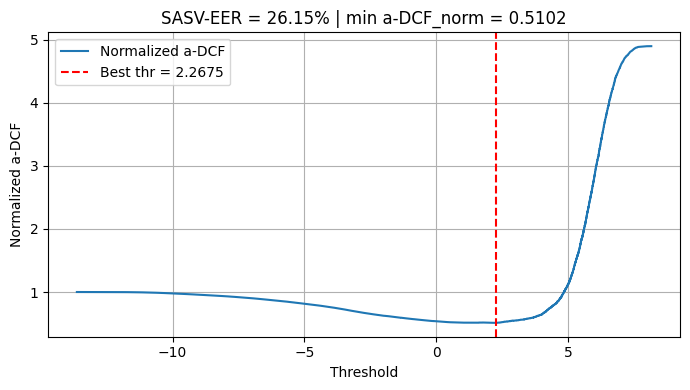

In [82]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ====== Paths ======
cm_path = "./origin_aasist.txt"
asv_path = "./origin_resnet.txt"

# ====== Load Data ======
df_cm = pd.read_csv(cm_path, sep=",")
df_asv = pd.read_csv(asv_path, sep=",")
print(f"CM: {len(df_cm):,} rows, ASV: {len(df_asv):,} rows")

# ====== Merge ======
df = pd.merge(df_asv, df_cm, on=["utt_id", "enroll_id", "label", "trial_type"], how="inner")
print(f"Merged: {len(df):,} rows")

# ====== Combined score ======
df["score_sum"] = df["cm_score"] + df["cosine_score"]

# ====== Binary label ======
# target=1, nontarget/spoof=0
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

print("\nTrial type distribution:")
print(df["trial_type"].value_counts())

# ====== SASV-EER  ======
try:
    fpr, tpr, thresholds = roc_curve(df["binary_label"], df["score_sum"])
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer_threshold = thresholds[eer_idx]
    sasv_eer = fpr[eer_idx] * 100
    print(f"\n✅ SASV-EER = {sasv_eer:.2f}% (threshold = {eer_threshold:.6f})")
except Exception as e:
    print(f"\n❌ EER calculation failed: {e}")
    eer_threshold = np.median(df["score_sum"])
    sasv_eer = np.nan
    print(f"Fallback threshold = {eer_threshold:.6f}")

# ====== a-DCF  ======
# Parameters from Shim et al. (2024)
C_miss, C_fa_non, C_fa_spf = 1, 10, 10
pi_tar, pi_non, pi_spf = 0.98, 0.01, 0.01

tar_scores = df[df["trial_type"] == "target"]["score_sum"]
non_scores = df[df["trial_type"] == "nontarget"]["score_sum"]
spf_scores = df[df["trial_type"] == "spoof"]["score_sum"]

# Sweep thresholds
all_scores = np.sort(df["score_sum"].unique())
adcf_values = []
for thr in all_scores:
    P_miss = np.mean(tar_scores < thr)
    P_fa_non = np.mean(non_scores >= thr)
    P_fa_spf = np.mean(spf_scores >= thr)
    adcf = (C_miss * pi_tar * P_miss
            + C_fa_non * pi_non * P_fa_non
            + C_fa_spf * pi_spf * P_fa_spf)
    adcf_values.append(adcf)
adcf_values = np.array(adcf_values)

# ====== Normalization ======
# a-DCF_def = min{ C_miss*pi_tar, C_fa_non*pi_non + C_fa_spf*pi_spf }
adcf_def = min(C_miss * pi_tar, C_fa_non * pi_non + C_fa_spf * pi_spf)
adcf_norm = adcf_values / adcf_def

# ====== min normalized a-DCF  ======
min_idx = np.argmin(adcf_norm)
best_thr = all_scores[min_idx]
min_adcf_norm = adcf_norm[min_idx]


P_miss_best = np.mean(tar_scores < best_thr)
P_fa_non_best = np.mean(non_scores >= best_thr)
P_fa_spf_best = np.mean(spf_scores >= best_thr)

print("\n===== Normalized a-DCF Results =====")
print(f"a-DCF_def = {adcf_def:.6f}")
print(f"Optimal threshold = {best_thr:.6f}")
print(f"P_miss = {P_miss_best:.6f}")
print(f"P_fa_non = {P_fa_non_best:.6f}")
print(f"P_fa_spf = {P_fa_spf_best:.6f}")
print(f"✅ Minimum normalized a-DCF = {min_adcf_norm:.6f}")

# ====== Plot ======
plt.figure(figsize=(7,4))
plt.plot(all_scores, adcf_norm, label="Normalized a-DCF")
plt.axvline(best_thr, color='r', linestyle='--', label=f"Best thr = {best_thr:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Normalized a-DCF")
plt.title(f"SASV-EER = {sasv_eer:.2f}% | min a-DCF_norm = {min_adcf_norm:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Score fusion v2

CM: 72,024 rows, ASV: 72,024 rows
Merged: 72,024 rows
CM normalization applied (min=0.000, max=1.000)

Trial type distribution:
spoof        33327
nontarget    33327
target        5370
Name: trial_type, dtype: int64

✅ SASV-EER = 1.89% (threshold = 1.425489)

===== Normalized a-DCF Results =====
a-DCF_def = 0.200000
Optimal threshold = 1.378657
P_miss = 0.008566
P_fa_non = 0.037417
P_fa_spf = 0.050860
 Minimum normalized a-DCF = 0.086112


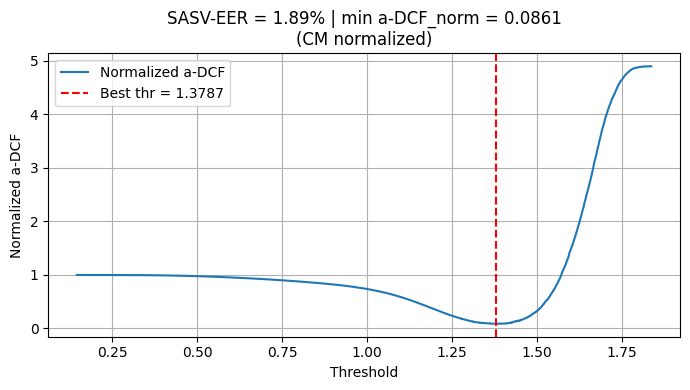

In [83]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ====== Paths ======
cm_path = "./origin_aasist.txt"
asv_path = "./origin_resnet.txt"

# ====== Load Data ======
df_cm = pd.read_csv(cm_path, sep=",")
df_asv = pd.read_csv(asv_path, sep=",")
print(f"CM: {len(df_cm):,} rows, ASV: {len(df_asv):,} rows")

# ====== Merge ======
df = pd.merge(df_asv, df_cm, on=["utt_id", "enroll_id", "label", "trial_type"], how="inner")
print(f"Merged: {len(df):,} rows")

# ====== CM Score Normalization ======
def normalize_scores(scores, method="minmax"):
    """Normalize CM scores (min-max or z-score)."""
    if method == "minmax":
        s_min, s_max = scores.min(), scores.max()
        return (scores - s_min) / (s_max - s_min + 1e-12)
    elif method == "zscore":
        mean, std = scores.mean(), scores.std()
        return (scores - mean) / (std + 1e-12)
    else:
        raise ValueError("method must be 'minmax' or 'zscore'")

df["cm_score_norm"] = normalize_scores(df["cm_score"], method="minmax")
print(f"CM normalization applied (min={df['cm_score_norm'].min():.3f}, max={df['cm_score_norm'].max():.3f})")

# ====== Combined score ======
df["score_sum"] = df["cm_score_norm"] + df["cosine_score"]

# ====== Binary label ======
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

print("\nTrial type distribution:")
print(df["trial_type"].value_counts())

# ====== SASV-EER ======
try:
    fpr, tpr, thresholds = roc_curve(df["binary_label"], df["score_sum"])
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer_threshold = thresholds[eer_idx]
    sasv_eer = fpr[eer_idx] * 100
    print(f"\n✅ SASV-EER = {sasv_eer:.2f}% (threshold = {eer_threshold:.6f})")
except Exception as e:
    print(f"\n❌ EER calculation failed: {e}")
    eer_threshold = np.median(df["score_sum"])
    sasv_eer = np.nan
    print(f"Fallback threshold = {eer_threshold:.6f}")

# ====== a-DCF  ======
# Parameters from Shim et al. (2024)
C_miss, C_fa_non, C_fa_spf = 1, 10, 10
pi_tar, pi_non, pi_spf = 0.98, 0.01, 0.01

tar_scores = df[df["trial_type"] == "target"]["score_sum"]
non_scores = df[df["trial_type"] == "nontarget"]["score_sum"]
spf_scores = df[df["trial_type"] == "spoof"]["score_sum"]

# Sweep thresholds
all_scores = np.sort(df["score_sum"].unique())
adcf_values = []
for thr in all_scores:
    P_miss = np.mean(tar_scores < thr)
    P_fa_non = np.mean(non_scores >= thr)
    P_fa_spf = np.mean(spf_scores >= thr)
    adcf = (C_miss * pi_tar * P_miss
            + C_fa_non * pi_non * P_fa_non
            + C_fa_spf * pi_spf * P_fa_spf)
    adcf_values.append(adcf)
adcf_values = np.array(adcf_values)

# ====== Normalized a-DCF ======
adcf_def = min(C_miss * pi_tar, C_fa_non * pi_non + C_fa_spf * pi_spf)
adcf_norm = adcf_values / adcf_def

min_idx = np.argmin(adcf_norm)
best_thr = all_scores[min_idx]
min_adcf_norm = adcf_norm[min_idx]

P_miss_best = np.mean(tar_scores < best_thr)
P_fa_non_best = np.mean(non_scores >= best_thr)
P_fa_spf_best = np.mean(spf_scores >= best_thr)

print("\n===== Normalized a-DCF Results =====")
print(f"a-DCF_def = {adcf_def:.6f}")
print(f"Optimal threshold = {best_thr:.6f}")
print(f"P_miss = {P_miss_best:.6f}")
print(f"P_fa_non = {P_fa_non_best:.6f}")
print(f"P_fa_spf = {P_fa_spf_best:.6f}")
print(f" Minimum normalized a-DCF = {min_adcf_norm:.6f}")

# ====== Plot ======
plt.figure(figsize=(7,4))
plt.plot(all_scores, adcf_norm, label="Normalized a-DCF")
plt.axvline(best_thr, color='r', linestyle='--', label=f"Best thr = {best_thr:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Normalized a-DCF")
plt.title(f"SASV-EER = {sasv_eer:.2f}% | min a-DCF_norm = {min_adcf_norm:.4f}\n(CM normalized)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Fixed

✅ Loaded 72,024 trials
  enroll_id        utt_id trial_type     score
0   LA_0044  LA_E_1109484  nontarget -0.341518
1   LA_0024  LA_E_3942685     target  0.997859
2   LA_0021  LA_E_9423808  nontarget -0.418083
3   LA_0045  LA_E_7706675  nontarget -0.391467
4   LA_0020  LA_E_9345935     target  0.998334
🔹 EER = 1.15% (threshold = 0.339741)
🔹 a-DCF_min (unnormalized) = 0.012148  (thr=0.132555)
🔹 a-DCF_def = 0.200000
🔹 a-DCF_min (normalized)   = 0.060742  (thr=0.132555)


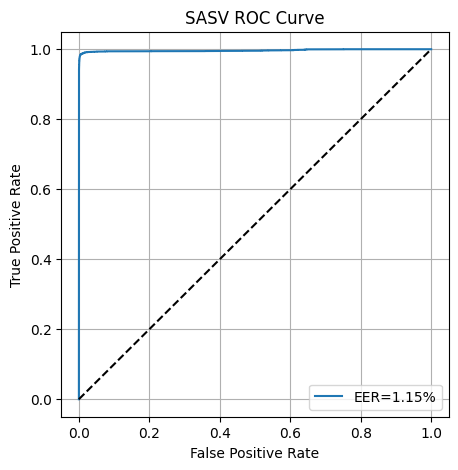

In [85]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ============================================================
# 1. Load File
# ============================================================
path_score = "./origin_fixed.txt"

df = pd.read_csv(path_score, sep=r"\s+", header=None,
                 names=["enroll_id", "utt_id", "trial_type", "score"])

print(f"✅ Loaded {len(df):,} trials")
print(df.head())

# ============================================================
# 2. Binary Label Conversion
# target = 1, nontarget/spoof = 0
# ============================================================
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

# ============================================================
# 3. EER Calculation
# ============================================================
fpr, tpr, thresholds = roc_curve(df["binary_label"], df["score"])
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_index] + fnr[eer_index]) / 2 * 100
eer_threshold = thresholds[eer_index]

print(f"🔹 EER = {eer:.2f}% (threshold = {eer_threshold:.6f})")

# ============================================================
# 4. a-DCF Calculation (Shim et al., 2024)
# ============================================================
C_miss = 1
C_fa_non = 10
C_fa_spf = 10
pi_tar = 0.98
pi_non = 0.01
pi_spf = 0.01
thr_list = np.linspace(df["score"].min(), df["score"].max(), 2000)
aDCF_list = []

for thr in thr_list:
    P_miss = np.mean(df[df["trial_type"] == "target"]["score"] < thr)
    P_fa_non = np.mean(df[df["trial_type"] == "nontarget"]["score"] >= thr)
    P_fa_spf = np.mean(df[df["trial_type"] == "spoof"]["score"] >= thr)

    aDCF = (
        C_miss * pi_tar * P_miss
        + C_fa_non * pi_non * P_fa_non
        + C_fa_spf * pi_spf * P_fa_spf
    )
    aDCF_list.append(aDCF)

min_aDCF = np.min(aDCF_list)
min_idx = np.argmin(aDCF_list)
min_thr = thr_list[min_idx]

aDCF_def = min(
    C_miss * pi_tar,
    C_fa_non * pi_non + C_fa_spf * pi_spf
)
aDCF_norm_list = np.array(aDCF_list) / aDCF_def
min_norm_aDCF = np.min(aDCF_norm_list)
min_norm_thr = thr_list[np.argmin(aDCF_norm_list)]

print(f"🔹 a-DCF_min (unnormalized) = {min_aDCF:.6f}  (thr={min_thr:.6f})")
print(f"🔹 a-DCF_def = {aDCF_def:.6f}")
print(f"🔹 a-DCF_min (normalized)   = {min_norm_aDCF:.6f}  (thr={min_norm_thr:.6f})")


# ============================================================
# 5. Plot ROC Curve
# ============================================================
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"EER={eer:.2f}%")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SASV ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


## Joint Optimization

✅ Loaded 72,024 trials
  enroll_id        utt_id trial_type     score
0   LA_0044  LA_E_1109484  nontarget  0.984251
1   LA_0024  LA_E_3942685     target  0.998741
2   LA_0021  LA_E_9423808  nontarget -0.280475
3   LA_0045  LA_E_7706675  nontarget -0.471314
4   LA_0020  LA_E_9345935     target  0.999090
🔹 EER = 1.60% (threshold = 0.989317)
🔹 a-DCF_min (unnormalized) = 0.015492  (thr=0.982252)
🔹 a-DCF_def = 0.200000
🔹 a-DCF_min (normalized)   = 0.077459  (thr=0.982252)


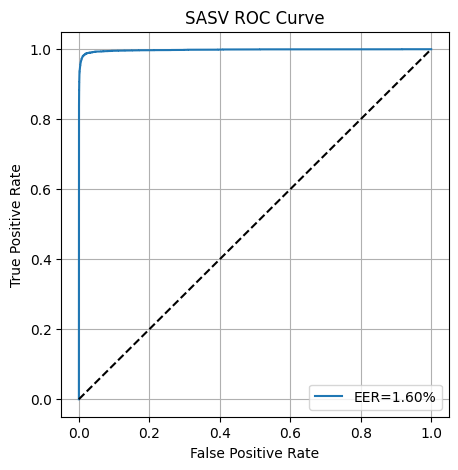

In [86]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ============================================================
# 1. Load File
# ============================================================
path_score = "./origin_joint.txt"

df = pd.read_csv(path_score, sep=r"\s+", header=None,
                 names=["enroll_id", "utt_id", "trial_type", "score"])

print(f"✅ Loaded {len(df):,} trials")
print(df.head())

# ============================================================
# 2. Binary Label Conversion
# target = 1, nontarget/spoof = 0
# ============================================================
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

# ============================================================
# 3. EER Calculation
# ============================================================
fpr, tpr, thresholds = roc_curve(df["binary_label"], df["score"])
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_index] + fnr[eer_index]) / 2 * 100
eer_threshold = thresholds[eer_index]

print(f"🔹 EER = {eer:.2f}% (threshold = {eer_threshold:.6f})")

# ============================================================
# 4. a-DCF Calculation (Shim et al., 2024)
# ============================================================
C_miss = 1
C_fa_non = 10
C_fa_spf = 10
pi_tar = 0.98
pi_non = 0.01
pi_spf = 0.01

thr_list = np.linspace(df["score"].min(), df["score"].max(), 2000)
aDCF_list = []

for thr in thr_list:
    P_miss = np.mean(df[df["trial_type"] == "target"]["score"] < thr)
    P_fa_non = np.mean(df[df["trial_type"] == "nontarget"]["score"] >= thr)
    P_fa_spf = np.mean(df[df["trial_type"] == "spoof"]["score"] >= thr)

    aDCF = (
        C_miss * pi_tar * P_miss
        + C_fa_non * pi_non * P_fa_non
        + C_fa_spf * pi_spf * P_fa_spf
    )
    aDCF_list.append(aDCF)
min_aDCF = np.min(aDCF_list)
min_idx = np.argmin(aDCF_list)
min_thr = thr_list[min_idx]

aDCF_def = min(
    C_miss * pi_tar,
    C_fa_non * pi_non + C_fa_spf * pi_spf
)

aDCF_norm_list = np.array(aDCF_list) / aDCF_def

min_norm_aDCF = np.min(aDCF_norm_list)
min_norm_thr = thr_list[np.argmin(aDCF_norm_list)]

print(f"🔹 a-DCF_min (unnormalized) = {min_aDCF:.6f}  (thr={min_thr:.6f})")
print(f"🔹 a-DCF_def = {aDCF_def:.6f}")
print(f"🔹 a-DCF_min (normalized)   = {min_norm_aDCF:.6f}  (thr={min_norm_thr:.6f})")

# ============================================================
# 5. Plot ROC Curve
# ============================================================
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"EER={eer:.2f}%")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SASV ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


## Cascading C-A

✅ Loaded: CM=72,024 rows | ASV=72,024 rows
✅ Merged: 72,024 rows

Trial type distribution:
spoof        33327
nontarget    33327
target        5370
Name: trial_type, dtype: int64

 SASV-EER = 3.38% (threshold = 0.607301)

===== Normalized a-DCF Results =====
a-DCF_def = 0.200000
Optimal threshold = 0.488801
P_miss = 0.002048
P_fa_non = 0.031026
P_fa_spf = 0.072734
Minimum normalized a-DCF = 0.061917


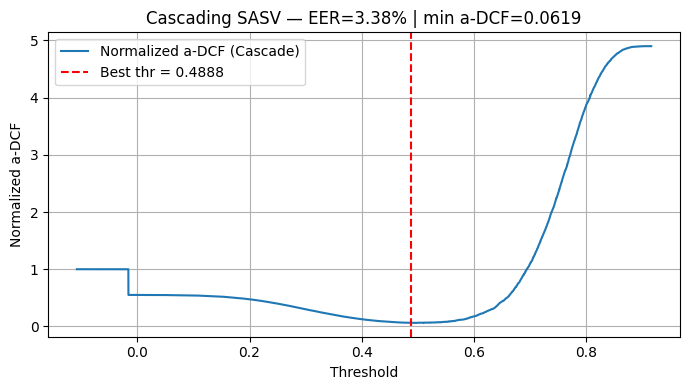

In [87]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ====== Paths ======
cm_path = "./origin_aasist.txt"
asv_path = "./origin_resnet.txt"

# ====== Parameters ======
CM_THRESHOLD = -1.1055   # AASIST LA19 dev thres
ASV_FAIL_SCORE = -0.0162 # minimum score

# ====== Load Data ======
df_cm = pd.read_csv(cm_path, sep=",")
df_asv = pd.read_csv(asv_path, sep=",")

print(f"✅ Loaded: CM={len(df_cm):,} rows | ASV={len(df_asv):,} rows")

# ====== Merge ======
df = pd.merge(df_asv, df_cm, on=["utt_id", "enroll_id", "label", "trial_type"], how="inner")
print(f"✅ Merged: {len(df):,} rows")

# ====== Cascading Rule ======
df["asv_cascade"] = np.where(df["cm_score"] >= CM_THRESHOLD, df["cosine_score"], ASV_FAIL_SCORE)

# ====== Binary Label ======
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

print("\nTrial type distribution:")
print(df["trial_type"].value_counts())

# ====== SASV-EER ======
fpr, tpr, thresholds = roc_curve(df["binary_label"], df["asv_cascade"])
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer_threshold = thresholds[eer_idx]
sasv_eer = fpr[eer_idx] * 100

print(f"\n SASV-EER = {sasv_eer:.2f}% (threshold = {eer_threshold:.6f})")

# ====== a-DCF ======
# Parameters from Shim et al. (2024)
C_miss, C_fa_non, C_fa_spf = 1, 10, 10
pi_tar, pi_non, pi_spf = 0.98, 0.01, 0.01

tar_scores = df[df["trial_type"] == "target"]["asv_cascade"]
non_scores = df[df["trial_type"] == "nontarget"]["asv_cascade"]
spf_scores = df[df["trial_type"] == "spoof"]["asv_cascade"]

# Sweep thresholds
all_scores = np.sort(df["asv_cascade"].unique())
adcf_values = []
for thr in all_scores:
    P_miss = np.mean(tar_scores < thr)
    P_fa_non = np.mean(non_scores >= thr)
    P_fa_spf = np.mean(spf_scores >= thr)
    adcf = (
        C_miss * pi_tar * P_miss
        + C_fa_non * pi_non * P_fa_non
        + C_fa_spf * pi_spf * P_fa_spf
    )
    adcf_values.append(adcf)
adcf_values = np.array(adcf_values)

# ====== Normalization ======
adcf_def = min(C_miss * pi_tar, C_fa_non * pi_non + C_fa_spf * pi_spf)
adcf_norm = adcf_values / adcf_def

# ====== min normalized a-DCF ======
min_idx = np.argmin(adcf_norm)
best_thr = all_scores[min_idx]
min_adcf_norm = adcf_norm[min_idx]

P_miss_best = np.mean(tar_scores < best_thr)
P_fa_non_best = np.mean(non_scores >= best_thr)
P_fa_spf_best = np.mean(spf_scores >= best_thr)

print("\n===== Normalized a-DCF Results =====")
print(f"a-DCF_def = {adcf_def:.6f}")
print(f"Optimal threshold = {best_thr:.6f}")
print(f"P_miss = {P_miss_best:.6f}")
print(f"P_fa_non = {P_fa_non_best:.6f}")
print(f"P_fa_spf = {P_fa_spf_best:.6f}")
print(f"Minimum normalized a-DCF = {min_adcf_norm:.6f}")

# ====== Plot ======
plt.figure(figsize=(7,4))
plt.plot(all_scores, adcf_norm, label="Normalized a-DCF (Cascade)")
plt.axvline(best_thr, color='r', linestyle='--', label=f"Best thr = {best_thr:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Normalized a-DCF")
plt.title(f"Cascading SASV — EER={sasv_eer:.2f}% | min a-DCF={min_adcf_norm:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Cascading A-C

Loaded CM=72,024, ASV=72,024
Merged total: 72,024

Trial type counts:
spoof        33327
nontarget    33327
target        5370
Name: trial_type, dtype: int64

 SASV-EER = 0.77% (threshold=0.638452)

===== Normalized a-DCF Results =====
a-DCF_def = 0.200000
Optimal threshold = 0.633425
P_miss = 0.007449
P_fa_non = 0.009452
P_fa_spf = 0.006181
Minimum normalized a-DCF = 0.044316


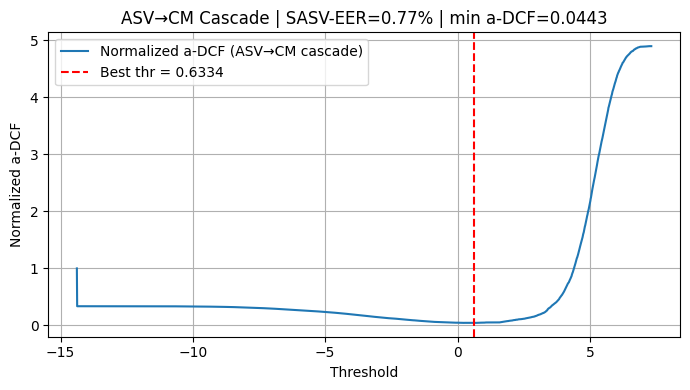

In [88]:
# %%
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
cm_path = "./origin_aasist.txt"
asv_path = "./origin_resnet.txt"

# ============================================================
#  Parameters
# ============================================================
ASV_THRESHOLD = 0.5325     # resnet34 ASV19 dev threshold
CM_FAIL_SCORE = -14.3855   # min score

# ============================================================
# Load Data
# ============================================================
df_cm = pd.read_csv(cm_path, sep=",")
df_asv = pd.read_csv(asv_path, sep=",")

print(f"Loaded CM={len(df_cm):,}, ASV={len(df_asv):,}")
df = pd.merge(df_asv, df_cm, on=["utt_id", "enroll_id", "label", "trial_type"], how="inner")
print(f"Merged total: {len(df):,}")

# ============================================================
# Cascade Rule
# ============================================================
def cascade_asv_first(row):
    if row["cosine_score"] >= ASV_THRESHOLD:
        return row["cm_score"]       
    else:
        return CM_FAIL_SCORE          

df["cascade_score"] = df.apply(cascade_asv_first, axis=1)

# ============================================================
# Binary Labels
# ============================================================
df["binary_label"] = df["trial_type"].apply(lambda x: 1 if x == "target" else 0)

print("\nTrial type counts:")
print(df["trial_type"].value_counts())

# ============================================================
# SASV-EER Calculation
# ============================================================
fpr, tpr, thresholds = roc_curve(df["binary_label"], df["cascade_score"])
fnr = 1 - tpr
idx = np.nanargmin(np.abs(fnr - fpr))
eer_thr = thresholds[idx]
sasv_eer = (fpr[idx] + fnr[idx]) / 2 * 100
print(f"\n SASV-EER = {sasv_eer:.2f}% (threshold={eer_thr:.6f})")

# ============================================================
# Normalized a-DCF Calculation
# ============================================================
C_miss, C_fa_non, C_fa_spf = 1, 10, 10
pi_tar, pi_non, pi_spf = 0.98, 0.01, 0.01

tar = df[df["trial_type"] == "target"]["cascade_score"]
non = df[df["trial_type"] == "nontarget"]["cascade_score"]
spf = df[df["trial_type"] == "spoof"]["cascade_score"]

all_scores = np.linspace(df["cascade_score"].min(), df["cascade_score"].max(), 2000)
adcf_vals = []

for thr in all_scores:
    P_miss = np.mean(tar < thr)
    P_fa_non = np.mean(non >= thr)
    P_fa_spf = np.mean(spf >= thr)
    adcf = (
        C_miss * pi_tar * P_miss
        + C_fa_non * pi_non * P_fa_non
        + C_fa_spf * pi_spf * P_fa_spf
    )
    adcf_vals.append(adcf)

adcf_vals = np.array(adcf_vals)

adcf_def = min(C_miss * pi_tar, C_fa_non * pi_non + C_fa_spf * pi_spf)
adcf_norm = adcf_vals / adcf_def

min_idx = np.argmin(adcf_norm)
best_thr = all_scores[min_idx]
min_adcf = adcf_norm[min_idx]

P_miss_best = np.mean(tar < best_thr)
P_fa_non_best = np.mean(non >= best_thr)
P_fa_spf_best = np.mean(spf >= best_thr)

print("\n===== Normalized a-DCF Results =====")
print(f"a-DCF_def = {adcf_def:.6f}")
print(f"Optimal threshold = {best_thr:.6f}")
print(f"P_miss = {P_miss_best:.6f}")
print(f"P_fa_non = {P_fa_non_best:.6f}")
print(f"P_fa_spf = {P_fa_spf_best:.6f}")
print(f"Minimum normalized a-DCF = {min_adcf:.6f}")

# ============================================================
#  Plot Results
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(all_scores, adcf_norm, label="Normalized a-DCF (ASV→CM cascade)")
plt.axvline(best_thr, color="r", linestyle="--", label=f"Best thr = {best_thr:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Normalized a-DCF")
plt.title(f"ASV→CM Cascade | SASV-EER={sasv_eer:.2f}% | min a-DCF={min_adcf:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
